Load and inspect the dataset

Read the CSV, check shape, data types, and the label distribution to confirm everything loaded correctly.

In [1]:
import pandas as pd
import numpy as np
import io
import os

# read the raw bytes of the zip file
with open(r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv', 'rb') as f:
    raw = f.read()

# pandas can read zip files directly using compression parameter
df = pd.read_csv(
    r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv',
    compression='zip'
)

print(df.shape)
print(df.head())
print(df['label'].value_counts())
print(df.isnull().sum()) # check missing values

(104345, 23)
      dt  switch       src       dst  pktcount  bytecount  dur   dur_nsec  \
0  11425       1  10.0.0.1  10.0.0.8     45304   48294064  100  716000000   
1  11605       1  10.0.0.1  10.0.0.8    126395  134737070  280  734000000   
2  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
3  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
4  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   

        tot_dur  flows  ...  pktrate  Pairflow  Protocol  port_no   tx_bytes  \
0  1.010000e+11      3  ...      451         0       UDP        3  143928631   
1  2.810000e+11      2  ...      451         0       UDP        4       3842   
2  2.010000e+11      3  ...      451         0       UDP        1       3795   
3  2.010000e+11      3  ...      451         0       UDP        2       3688   
4  2.010000e+11      3  ...      451         0       UDP        3       3413   

  rx_bytes  tx_kbps  rx_kbps  tot_kbps  lab

Handle missing values

Your dataset has 506 missing values in rx_kbps and tot_kbps. Fill them with the column median — a safe choice for skewed network traffic data.

In [2]:
df['rx_kbps'].fillna(df['rx_kbps'].median())
df['tot_kbps'].fillna(df['tot_kbps'].median())

print(df.isnull().sum().sum())  # should print 0

1012


FEATURE ENGINEERING

In [3]:
# Ratio features — capture relationships between raw counts
df['bytes_per_packet'] = df['bytecount'] / (df['pktcount'] + 1)
df['tx_rx_ratio']      = df['tx_bytes']  / (df['rx_bytes'] + 1)
df['kbps_per_flow']    = df['tot_kbps']  / (df['flows'] + 1)
df['pkt_per_second']   = df['pktcount']  / (df['tot_dur'] + 1)

# Interaction features — combinations that together signal attacks
df['rate_x_flows']      = df['pktrate']   * df['flows']
df['bandwidth_x_pkts']  = df['tot_kbps']  * df['pktcount']
df['packetins_x_flows'] = df['packetins'] * df['flows']

# Confirm new features were added
print(f"New shape: {df.shape}")     # should show 23 + 7 = 30 columns
print("New columns added:")
print([c for c in df.columns if c not in [
    'dt','switch','src','dst','pktcount','bytecount','dur',
    'dur_nsec','tot_dur','flows','packetins','pktperflow',
    'byteperflow','pktrate','Pairflow','Protocol','port_no',
    'tx_bytes','rx_bytes','tx_kbps','rx_kbps','tot_kbps','label'
]])

New shape: (104345, 30)
New columns added:
['bytes_per_packet', 'tx_rx_ratio', 'kbps_per_flow', 'pkt_per_second', 'rate_x_flows', 'bandwidth_x_pkts', 'packetins_x_flows']


Encode categorical features

Three columns are non-numeric: src, dst, and Protocol. Encode them so the model can use them.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['src']      = le.fit_transform(df['src'].astype(str))
df['dst']      = le.fit_transform(df['dst'].astype(str))
df['Protocol'] = le.fit_transform(df['Protocol'].astype(str))

print(df[['src','dst','Protocol']].head())

   src  dst  Protocol
0    0   16         2
1    0   16         2
2   10   16         2
3   10   16         2
4   10   16         2


Split features and target, then train/test split

Separate X (features) from y (label), then split into 80% training and 20% test set. Stratify to preserve the class ratio in both sets.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 61/39 ratio in both splits
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (83476, 29), Test: (20869, 29)


No feature scaling needed

Random Forest is a collection of Decision Trees, so like DT it is completely scale-invariant. Use raw X_train and X_test directly.

In [6]:
# Random Forest does NOT need scaling either
# Use the same raw X_train and X_test as Decision Tree

print("Ready to train Random Forest on:")
print(f"  Train: {X_train.shape}")
print(f"  Test : {X_test.shape}")

Ready to train Random Forest on:
  Train: (83476, 29)
  Test : (20869, 29)


Train the Random Forest model

Random Forest builds 100 independent decision trees on random subsets of data and features, then takes a majority vote. n_jobs=-1 uses all CPU cores to train trees in parallel.

In [7]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=10,       # max depth per tree
    random_state=42,
    n_jobs=-1           # use all CPU cores — much faster
)

start = time.time()
rf_model.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Training time: 1.39s


Calculate all performance metrics

Same evaluation block as before. Random Forest should noticeably outperform both Logistic Regression and Decision Tree here.

In [8]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

print("=== Random Forest Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Normal', 'DDoS']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy : 0.9977
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     12712
        DDoS       0.99      1.00      1.00      8157

    accuracy                           1.00     20869
   macro avg       1.00      1.00      1.00     20869
weighted avg       1.00      1.00      1.00     20869


Confusion Matrix:
[[12669    43]
 [    4  8153]]


Plot confusion matrix and ROC curve

Same structure as before, using green color scheme for Random Forest to visually distinguish it in your report.

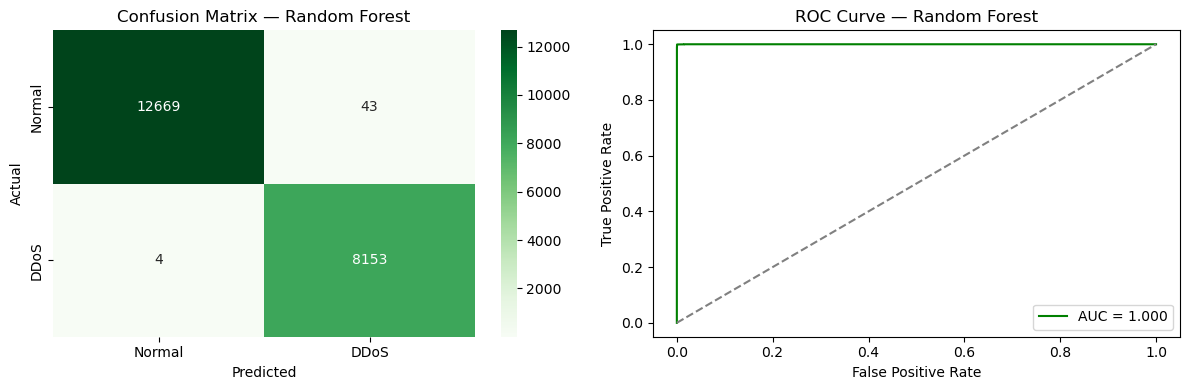

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'DDoS'],
            yticklabels=['Normal', 'DDoS'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='green')
axes[1].plot([0,1], [0,1], '--', color='gray')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150)
plt.show()

Plot feature importance

Random Forest averages feature importance across all 100 trees, giving a much more stable and reliable importance ranking than a single Decision Tree.

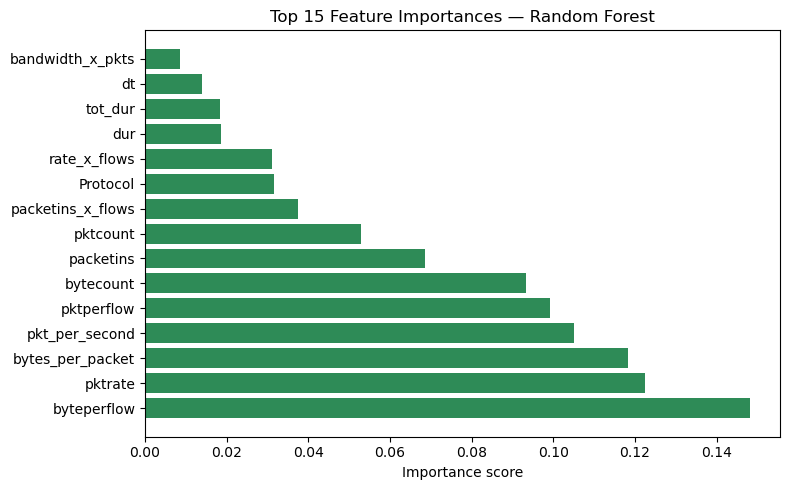

Top 5 features driving DDoS detection:
             feature  importance
12       byteperflow    0.148139
13           pktrate    0.122480
22  bytes_per_packet    0.118280
25    pkt_per_second    0.105126
11        pktperflow    0.099260


In [10]:
feat_imp_rf = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_rf['feature'], feat_imp_rf['importance'],
         color='seagreen')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

# Print top 5 most important features
print("Top 5 features driving DDoS detection:")
print(feat_imp_rf.head())

Store metrics for final comparison

Add Random Forest to the results dictionary. You should now see 3 models lined up in your comparison table.

In [12]:
results = {}
report_rf = classification_report(y_test, y_pred_rf,
               output_dict=True)

results['Random Forest'] = {
    'accuracy' : accuracy_score(y_test, y_pred_rf),
    'roc_auc'  : roc_auc_score(y_test, y_prob_rf),
    'precision': report_rf['1']['precision'],
    'recall'   : report_rf['1']['recall'],
    'f1'       : report_rf['1']['f1-score'],
}

# Preview comparison so far (LR + DT + RF)
print(pd.DataFrame(results).T.round(4))

               accuracy  roc_auc  precision  recall      f1
Random Forest    0.9977      1.0     0.9948  0.9995  0.9971
